# FI-2010 Reproduction — DeepLOB & MLPLOB

**Goal (sprint Day 1):** reproduce the FI-2010 classification baselines and **save results + checkpoints**
(the foundation that was lost in the earlier ephemeral run). Runs DeepLOB and MLPLOB across horizons
k ∈ {10, 20, 50, 100} on the standard CF_7 split, computes full metrics (macro/weighted F1, per-class
P/R, MCC, confusion), runs the acceptance test, and persists everything to S3 / Drive.

### How to use
1. **Runtime → Change runtime type → GPU (T4 is fine).**
2. Run the cells top to bottom. Cell 2 fetches the project code (set `REPO_URL` after you push the repo,
   or use the upload fallback). Cell 4 gets the FI-2010 data (Kaggle or a path you provide).
3. Full run takes roughly **1–3 h on a T4** (8 experiments × early-stopped training).

> Mamba is **not** needed here — DeepLOB and MLPLOB don't import `mamba-ssm`. The Mamba runs come later, in their own notebook.


## 1. Runtime check

In [1]:
import platform, torch
print("Python:", platform.python_version(), "| Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: No GPU detected. Runtime > Change runtime type > Hardware accelerator > GPU.")

Python: 3.12.13 | Torch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Get the project code

The repo is **private**, so the git-clone path needs a token. Options:
- **Colab Secrets** (recommended): add a GitHub PAT (scope `repo`) as a secret named `GH_PAT`
  (key icon in the left sidebar); this cell reads it automatically.
- Or paste a token into `GITHUB_TOKEN` below.
- Or skip cloning and use the **upload fallback** cell (select `models.py`, `fi2010_dataset.py`, `train.py`).

In [2]:
import sys, subprocess, pathlib

REPO_URL = "https://github.com/rajjoseph48/nse-lob-capstone.git"   # private repo
REPO_DIR = "nse-lob-capstone"

GITHUB_TOKEN = ""                       # paste a PAT here, or leave blank to use Colab Secrets
try:
    from google.colab import userdata   # auto-read PAT stored as Colab secret "GH_PAT"
    GITHUB_TOKEN = GITHUB_TOKEN or (userdata.get("GH_PAT") or "")
except Exception:
    pass

def add_modeling(base):
    base = pathlib.Path(base)
    for cand in (base / "modeling", base):          # repo root or modeling/ itself
        if (cand / "models.py").exists():
            sys.path.insert(0, str(cand.resolve()))
            return str(cand.resolve())
    return None

path = None
for c in (".", REPO_DIR, "/content/" + REPO_DIR):    # already checked out?
    path = add_modeling(c)
    if path:
        break
if not path:                                         # else clone (token for private repo)
    url = REPO_URL.replace("https://", f"https://{GITHUB_TOKEN}@") if GITHUB_TOKEN else REPO_URL
    subprocess.run(["git", "clone", "--depth", "1", url], check=True)
    path = add_modeling(REPO_DIR)

print("modeling/ on sys.path:", path or "NOT FOUND — add a PAT or use the upload fallback cell")

modeling/ on sys.path: /content/nse-lob-capstone/modeling


**Upload fallback** (only if you did not git-clone above):

In [ ]:
# from google.colab import files
# files.upload()                       # select models.py, fi2010_dataset.py, train.py
# import sys; sys.path.insert(0, ".")

## 3. Verify dependencies

In [3]:
import importlib, subprocess, sys
for pkg in ["sklearn", "seaborn", "pandas", "matplotlib", "tqdm"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        {"sklearn": "scikit-learn"}.get(pkg, pkg)])
import sklearn, seaborn, pandas, matplotlib  # noqa
print("dependencies ok")

dependencies ok


## 4. Get FI-2010 data

The loader expects the **`NoAuction_Zscore`** folder (pre-normalized; do *not* re-normalize), with
`NoAuction_Zscore_Training/` and `NoAuction_Zscore_Testing/` subfolders containing `*CF_7.txt`.

- If you already have the data on Drive/S3, set `DATA_DIR` to that folder and skip the Kaggle cell.
- Otherwise use the Kaggle cell (needs `kaggle.json`). Verify `KAGGLE_SLUG` matches an FI-2010 dataset.

In [4]:
import pathlib

DATA_DIR = ""   # <-- set to your NoAuction_Zscore folder if you already have the data

def find_zscore_dir(root):
    """Locate the NoAuction_Zscore folder anywhere under `root`."""
    root = pathlib.Path(root)
    if (root / "NoAuction_Zscore_Training").exists():
        return root
    for p in root.rglob("*"):
        if p.is_dir() and "zscore" in p.name.lower():
            subs = [c.name.lower() for c in p.iterdir() if c.is_dir()]
            if any("train" in s for s in subs):
                return p
    return None

**Kaggle download** (skip if `DATA_DIR` is already set):

In [5]:
KAGGLE_SLUG = "ulfricirons/fi-2010"   # FI-2010 benchmark (full BenchmarkDatasets/ structure)
KAGGLE_USERNAME = ""                   # your kaggle handle (kaggle.com/<username>)
KAGGLE_KEY = ""                        # the API token string

if not DATA_DIR:
    import os
    # 1) Colab Secrets (if you stored them there)
    try:
        from google.colab import userdata
        KAGGLE_USERNAME = KAGGLE_USERNAME or (userdata.get("KAGGLE_USERNAME") or "")
        KAGGLE_KEY = KAGGLE_KEY or (userdata.get("KAGGLE_KEY") or "")
    except Exception:
        pass
    if KAGGLE_USERNAME and KAGGLE_KEY:
        os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME
        os.environ["KAGGLE_KEY"] = KAGGLE_KEY
    # 2) else upload a kaggle.json
    elif not os.environ.get("KAGGLE_KEY"):
        from google.colab import files
        print("No KAGGLE_USERNAME/KAGGLE_KEY set — upload kaggle.json instead")
        files.upload()
        !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
    !pip -q install kaggle
    !kaggle datasets download -d {KAGGLE_SLUG} -p fi2010_data --unzip
    found = find_zscore_dir("fi2010_data")
    DATA_DIR = str(found) if found else ""

assert DATA_DIR and find_zscore_dir(DATA_DIR), \
    "NoAuction_Zscore folder not found. Set DATA_DIR manually."
DATA_DIR = str(find_zscore_dir(DATA_DIR))
print("DATA_DIR =", DATA_DIR)

Dataset URL: https://www.kaggle.com/datasets/ulfricirons/fi-2010
License(s): unknown
100% 1.95G/1.95G [00:28<00:00, 74.5MB/s]



AssertionError: NoAuction_Zscore folder not found. Set DATA_DIR manually.

In [6]:
import zipfile, pathlib
root = pathlib.Path("fi2010_data")
print("top-level:", sorted(p.name for p in root.iterdir()))

for z in list(root.rglob("*.zip")):          # extract nested zip(s) --unzip left
    # behind
  print("extracting nested zip:", z.name)
  with zipfile.ZipFile(z) as zf:
    zf.extractall(z.parent)

def find_zscore_dir(root):
    root = pathlib.Path(root)
    for p in root.rglob("*"):                # the actual loader subfolder
        if p.is_dir() and p.name.lower() == "noauction_zscore_training":
            return p.parent
    for p in root.rglob("*"):                # fallback: any NoAuction Zscore dir
      if p.is_dir() and "zscore" in p.name.lower() and "noauction" in p.name.lower():
        return p
DATA_DIR = str(find_zscore_dir("fi2010_data"))
print("DATA_DIR =", DATA_DIR)

top-level: ['BenchmarkDatasets']
DATA_DIR = fi2010_data/BenchmarkDatasets/NoAuction/1.NoAuction_Zscore


## 5. Smoke test — DeepLOB, k=10, 3 epochs (confirm the pipeline learns)

In [7]:
from fi2010_dataset import load_fi2010
from models import build_model
from train import train, evaluate, DEVICE

tr, vl, te = load_fi2010(DATA_DIR, fold=7, horizon=10, seq_len=100)
m = build_model("deeplob")
print("DeepLOB params:", sum(p.numel() for p in m.parameters()))
_ = train(m, tr, vl, epochs=3, patience=3, batch_size=128, verbose=True)
print("smoke eval (weighted-F1/acc/loss):", evaluate(m, te))

Using device: cuda

Loading FI-2010 | fold=CF_7 | horizon=k10 | seq_len=100
  Train: Train_Dst_NoAuction_ZScore_CF_7.txt  (149×254750 on disk → 254750×149 after transpose)
  Test:  Test_Dst_NoAuction_ZScore_CF_7.txt  (149×55478 on disk → 55478×149 after transpose)
  Parsing text files (one-time, ~60s) ...
  Cache saved → fi2010_data/BenchmarkDatasets/NoAuction/1.NoAuction_Zscore/.cache_cf7.npz (future loads will be ~1s)
  Splits → train: 229,176  val: 25,376  test: 55,379
    train labels: Down:19.9%  Stat:60.0%  Up:20.0%
    test  labels: Down:14.0%  Stat:73.3%  Up:12.7%
DeepLOB params: 191351
  epoch   1 | train_loss 0.7656 | val_loss 0.7439 | val_f1 0.7270 ← best
smoke eval (weighted-F1/acc/loss): {'f1': 0.8286, 'acc': 0.8268, 'loss': 0.51}


## 6. Metrics helper (full classification report)

In [8]:
import numpy as np, torch
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                             matthews_corrcoef, confusion_matrix)
from fi2010_dataset import make_loader
from train import DEVICE

CLASS_NAMES = ["Down", "Stat", "Up"]

def collect_preds(model, ds, batch_size=256):
    model = model.to(DEVICE).eval()
    loader = make_loader(ds, batch_size=batch_size, shuffle=False)
    preds, labels = [], []
    with torch.no_grad():
        for X, y in loader:
            preds.append(model(X.to(DEVICE)).argmax(1).cpu().numpy())
            labels.append(y.numpy())
    return np.concatenate(preds), np.concatenate(labels)

def full_metrics(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1, 2], zero_division=0)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
        "per_class": {CLASS_NAMES[i]: {"precision": float(p[i]), "recall": float(r[i]),
                                       "f1": float(f[i])} for i in range(3)},
        "confusion": confusion_matrix(y_true, y_pred, labels=[0, 1, 2]).tolist(),
    }

## 7. Single-experiment runner

Trains one (model, horizon), evaluates with full metrics, saves a checkpoint, and **appends to the
results CSV after every run** (resilient to disconnects). Per-experiment full metrics (per-class +
confusion) are also dumped to JSON.

In [9]:
import time, json, pathlib, pandas as pd
from fi2010_dataset import load_fi2010
from models import build_model
from train import train, save_checkpoint

RESULTS_DIR = pathlib.Path("results"); RESULTS_DIR.mkdir(exist_ok=True)
CKPT_DIR = pathlib.Path("checkpoints/fi2010"); CKPT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CSV = RESULTS_DIR / "fi2010_reproduction.csv"

def run_experiment(model_name, horizon, fold=7, epochs=50, batch_size=128, seq_len=100):
    tag = f"{model_name}_cf{fold}_h{horizon}"
    print("=" * 70); print(" ", tag); print("=" * 70)
    tr, vl, te = load_fi2010(DATA_DIR, fold=fold, horizon=horizon, seq_len=seq_len)
    model = build_model(model_name)
    n_params = sum(p.numel() for p in model.parameters())
    t0 = time.time()
    hist = train(model, tr, vl, epochs=epochs, batch_size=batch_size, verbose=True)
    elapsed = time.time() - t0
    y_pred, y_true = collect_preds(model, te)
    mt = full_metrics(y_true, y_pred)
    ckpt = CKPT_DIR / f"{tag}.pt"; save_checkpoint(model, str(ckpt))
    row = {"model": model_name, "fold": fold, "horizon": horizon, "n_params": n_params,
           "best_epoch": hist["best_epoch"], "epochs_run": len(hist["val_f1"]),
           "best_val_f1": round(max(hist["val_f1"]), 4),
           "test_accuracy": round(mt["accuracy"], 4),
           "test_macro_f1": round(mt["macro_f1"], 4),
           "test_weighted_f1": round(mt["weighted_f1"], 4),
           "test_mcc": round(mt["mcc"], 4),
           "train_time_s": round(elapsed, 1), "checkpoint": str(ckpt)}
    df = pd.read_csv(RESULTS_CSV) if RESULTS_CSV.exists() else pd.DataFrame()
    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    df.to_csv(RESULTS_CSV, index=False)
    with open(RESULTS_DIR / f"{tag}_metrics.json", "w") as fjs:
        json.dump(mt, fjs, indent=2)
    print(f"  -> macro_f1={mt['macro_f1']:.4f}  weighted_f1={mt['weighted_f1']:.4f}  "
          f"acc={mt['accuracy']:.4f}  ({elapsed:.0f}s)")
    return row, mt

## 8. Full reproduction run

DeepLOB + MLPLOB × horizons {10, 20, 50, 100}. `EPOCHS=50` with early stopping (patience 10).
To resume after a disconnect, just re-run — completed rows are already in the CSV; delete rows you
want to redo.

In [10]:
MODELS = ["deeplob", "mlplob"]
HORIZONS = [10, 20, 50, 100]
EPOCHS = 50

all_metrics = {}
done = set()
if RESULTS_CSV.exists():
    _d = pd.read_csv(RESULTS_CSV)
    done = {(r.model, int(r.horizon)) for r in _d.itertuples()}

for mdl in MODELS:
    for h in HORIZONS:
        if (mdl, h) in done:
            print(f"skip {mdl} h{h} (already in CSV)"); continue
        _, mt = run_experiment(mdl, h, epochs=EPOCHS)
        all_metrics[f"{mdl}_h{h}"] = mt

pd.read_csv(RESULTS_CSV)

  deeplob_cf7_h10

Loading FI-2010 | fold=CF_7 | horizon=k10 | seq_len=100
  Loading from cache: fi2010_data/BenchmarkDatasets/NoAuction/1.NoAuction_Zscore/.cache_cf7.npz
  Splits → train: 229,176  val: 25,376  test: 55,379
    train labels: Down:19.9%  Stat:60.0%  Up:20.0%
    test  labels: Down:14.0%  Stat:73.3%  Up:12.7%
  epoch   1 | train_loss 0.7738 | val_loss 0.7356 | val_f1 0.7281 ← best
  epoch   5 | train_loss 0.5850 | val_loss 0.6873 | val_f1 0.7333
  epoch  10 | train_loss 0.4402 | val_loss 0.8144 | val_f1 0.7313
  Early stop at epoch 14 (best epoch 4).
  -> macro_f1=0.7192  weighted_f1=0.8250  acc=0.8205  (834s)
  deeplob_cf7_h20

Loading FI-2010 | fold=CF_7 | horizon=k20 | seq_len=100
  Loading from cache: fi2010_data/BenchmarkDatasets/NoAuction/1.NoAuction_Zscore/.cache_cf7.npz
  Splits → train: 229,176  val: 25,376  test: 55,379
    train labels: Down:25.6%  Stat:48.7%  Up:25.6%
    test  labels: Down:18.4%  Stat:65.4%  Up:16.2%
  epoch   1 | train_loss 0.8562 | val_los

,model,fold,horizon,n_params,best_epoch,epochs_run,best_val_f1,test_accuracy,test_macro_f1,test_weighted_f1,test_mcc,train_time_s,checkpoint
0,deeplob,7,10,191351,4,14,0.7569,0.8205,0.7192,0.8250,0.6008,834.4,checkpoints/fi2010/deeplob_cf7_h10.pt
1,deeplob,7,20,191351,6,16,0.6535,0.7208,0.6323,0.7243,0.4678,950.9,checkpoints/fi2010/deeplob_cf7_h20.pt
2,deeplob,7,50,191351,3,13,0.7223,0.7995,0.7722,0.7981,0.6729,773.6,checkpoints/fi2010/deeplob_cf7_h50.pt
3,deeplob,7,100,191351,3,13,0.7074,0.7925,0.7856,0.7915,0.6857,772.4,checkpoints/fi2010/deeplob_cf7_h100.pt
4,mlplob,7,10,529411,1,11,0.5155,0.5918,0.4291,0.6115,0.1414,84.4,checkpoints/fi2010/mlplob_cf7_h10.pt
5,mlplob,7,20,529411,7,17,0.3949,0.5062,0.4066,0.5213,0.1201,132.6,checkpoints/fi2010/mlplob_cf7_h20.pt
6,mlplob,7,50,529411,1,11,0.3260,0.4835,0.4469,0.4858,0.1713,85.7,checkpoints/fi2010/mlplob_cf7_h50.pt
7,mlplob,7,100,529411,44,50,0.5110,0.4900,0.4861,0.4801,0.2524,387.4,checkpoints/fi2010/mlplob_cf7_h100.pt


## 9. Acceptance test

DeepLOB on FI-2010 k=10 should land in the literature ballpark (Zhang et al. 2019 report ~83.4 F1).
We accept a macro-F1 in **78–86%**; well below that points to a label-mapping / normalization / under-training issue.

In [16]:
res = pd.read_csv(RESULTS_CSV)
row = res[(res.model == "deeplob") & (res.horizon == 10)]
if len(row):
    mf1 = float(row.test_macro_f1.iloc[0]) * 100
    wf1 = float(row.test_weighted_f1.iloc[0]) * 100
    print(f"DeepLOB k=10 -> weighted-F1 {wf1:.2f}% (paper ~83.4)  |  macro-F1 {mf1:.2f}%")
    print("ACCEPTANCE (vs paper headline, weighted-F1):",
          "PASS ✓" if 78 <= wf1 <= 88 else "REVIEW ✗ (labels / normalization / epochs)")
    print(f"macro-F1 {mf1:.1f}% — expected ~70-75%, consistent with LOBCAST/Prata 2023 reproductions"
          + (" ✓" if 65 <= mf1 <= 80 else " (outside the usual repro range — inspect)"))
else:
    print("Run DeepLOB h10 first (cell 8).")

DeepLOB k=10 -> weighted-F1 82.50% (paper ~83.4)  |  macro-F1 71.92%
ACCEPTANCE (vs paper headline, weighted-F1): PASS ✓
macro-F1 71.9% — expected ~70-75%, consistent with LOBCAST/Prata 2023 reproductions ✓


## 10. Results table + figures

model    deeplob  mlplob
horizon                 
10        0.7192  0.4291
20        0.6323  0.4066
50        0.7722  0.4469
100       0.7856  0.4861


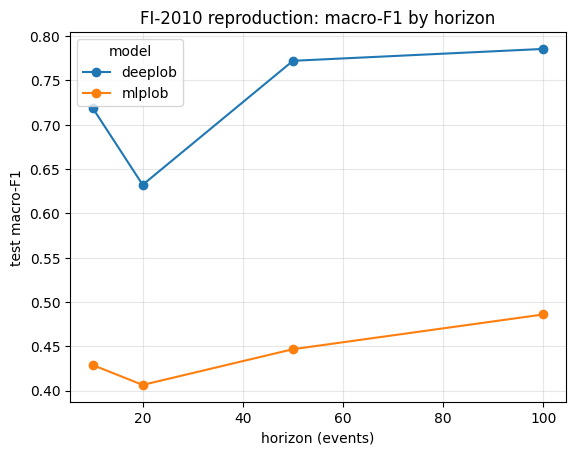

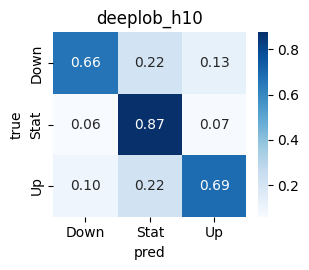

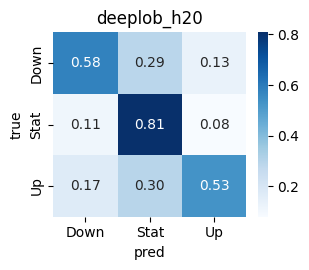

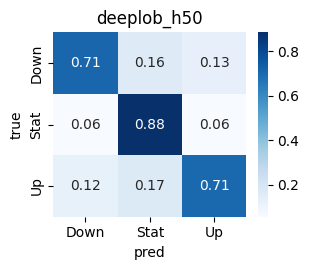

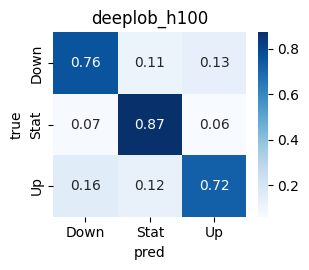

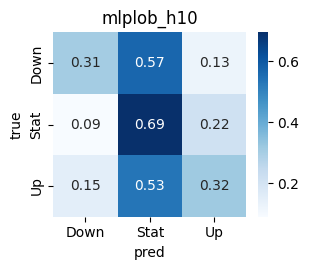

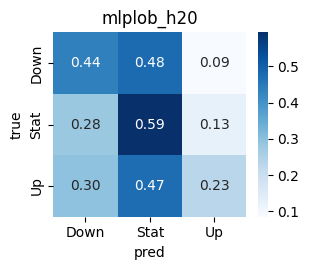

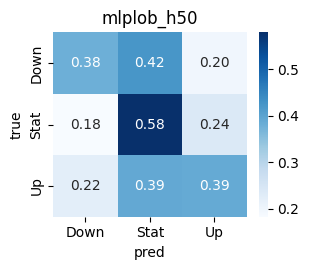

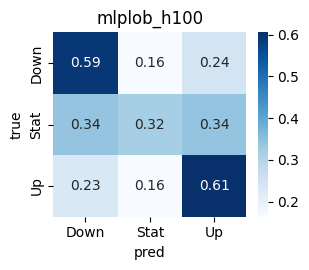

In [17]:
import matplotlib.pyplot as plt, seaborn as sns, numpy as np

res = pd.read_csv(RESULTS_CSV)
pivot = res.pivot_table(index="horizon", columns="model", values="test_macro_f1")
print(pivot.round(4).to_string())

ax = pivot.plot(marker="o")
ax.set_ylabel("test macro-F1"); ax.set_xlabel("horizon (events)")
ax.set_title("FI-2010 reproduction: macro-F1 by horizon"); ax.grid(True, alpha=0.3)
plt.savefig(RESULTS_DIR / "fig_macrof1_by_horizon.png", dpi=150, bbox_inches="tight"); plt.show()

# Confusion matrices for whatever ran this session
for key, mt in all_metrics.items():
    cm = np.array(mt["confusion"], dtype=float); cmn = cm / cm.sum(1, keepdims=True)
    plt.figure(figsize=(3.2, 2.8))
    sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(key); plt.ylabel("true"); plt.xlabel("pred"); plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"cm_{key}.png", dpi=150, bbox_inches="tight"); plt.show()

## 11. Persist results + checkpoints

**Do this before the runtime disconnects.** Use Drive (simplest) and/or S3.

In [14]:
!pip -q install boto3
import os
from google.colab import userdata
os.environ["AWS_ACCESS_KEY_ID"]     = userdata.get("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = userdata.get("AWS_SECRET_ACCESS_KEY")
import boto3, glob
s3 = boto3.client("s3", region_name="ap-south-2")
for f in glob.glob("results/*") + glob.glob("checkpoints/fi2010/*"):
    key = f"reproduction/fi2010/{f}"; s3.upload_file(f, "lob-capstone-data", key);
print("uploaded", key)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.2/15.2 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 10.1 MB/s eta 0:00:00
uploaded reproduction/fi2010/checkpoints/fi2010/mlplob_cf7_h20.pt


In [13]:
# --- Option A: Google Drive ---
# from google.colab import drive; drive.mount("/content/drive")
# import shutil
# dst = "/content/drive/MyDrive/fi2010_repro"
# shutil.copytree("results", dst + "/results", dirs_exist_ok=True)
# shutil.copytree("checkpoints", dst + "/checkpoints", dirs_exist_ok=True)
# print("copied to", dst)

# --- Option B: S3 (bucket lob-capstone-data, region ap-south-2) ---
import os, glob
S3_BUCKET, S3_PREFIX, S3_REGION = "lob-capstone-data", "reproduction/fi2010", "ap-south-2"
# Provide credentials (or skip this cell and use Drive):
# os.environ["AWS_ACCESS_KEY_ID"] = "..."
# os.environ["AWS_SECRET_ACCESS_KEY"] = "..."
try:
    import boto3
    s3 = boto3.client("s3", region_name=S3_REGION)
    for f in glob.glob("results/*") + glob.glob("checkpoints/fi2010/*"):
        key = f"{S3_PREFIX}/{f}"
        s3.upload_file(f, S3_BUCKET, key); print("uploaded", key)
    print(f"Done -> s3://{S3_BUCKET}/{S3_PREFIX}/")
except Exception as e:
    print("S3 upload skipped:", repr(e))

S3 upload skipped: ModuleNotFoundError("No module named 'boto3'")


## 12. Reproduction comparison table (ours vs published)

Fill in `PUBLISHED` from the papers before citing. DeepLOB k=10 (~83.4, Zhang 2019) is the anchor;
MLPLOB numbers come from Berti et al. 2025. Numbers below are **placeholders to verify**, not asserted.

In [18]:
PUBLISHED = {            # avg/weighted F1 (%) as commonly reported — CONFIRM against the papers
    ("deeplob", 10): 83.4,
    ("deeplob", 20): None, ("deeplob", 50): None, ("deeplob", 100): None,
    ("mlplob", 10): None, ("mlplob", 20): None, ("mlplob", 50): None, ("mlplob", 100): None,
    ("tlob", 10): 92.8, ("tlob", 20): None, ("tlob", 50): None, ("tlob", 100): None,
}
res = pd.read_csv(RESULTS_CSV)
res["ours_macro_f1_%"] = (res.test_macro_f1 * 100).round(2)
res["ours_weighted_f1_%"] = (res.test_weighted_f1 * 100).round(2)
res["published_f1"] = res.apply(lambda r: PUBLISHED.get((r.model, int(r.horizon))), axis=1)
res["delta_vs_pub"] = (res["ours_weighted_f1_%"] - res["published_f1"]).round(2)
cols = ["model", "horizon", "ours_macro_f1_%", "ours_weighted_f1_%", "published_f1",
        "delta_vs_pub", "test_accuracy", "best_epoch", "train_time_s"]
res[cols].sort_values(["model", "horizon"])

,model,horizon,ours_macro_f1_%,ours_weighted_f1_%,published_f1,delta_vs_pub,test_accuracy,best_epoch,train_time_s
0,deeplob,10,71.92,82.50,83.4,-0.9,0.8205,4,834.4
1,deeplob,20,63.23,72.43,NaN,NaN,0.7208,6,950.9
2,deeplob,50,77.22,79.81,NaN,NaN,0.7995,3,773.6
3,deeplob,100,78.56,79.15,NaN,NaN,0.7925,3,772.4
4,mlplob,10,42.91,61.15,NaN,NaN,0.5918,1,84.4
5,mlplob,20,40.66,52.13,NaN,NaN,0.5062,7,132.6
6,mlplob,50,44.69,48.58,NaN,NaN,0.4835,1,85.7
7,mlplob,100,48.61,48.01,NaN,NaN,0.4900,44,387.4
